# 🧠 Алгоритми та структури даних · Урок 1 — Складність та рекурсія

Це **бонусний розділ** курсу — фундамент, який вивчають в університетах у дисципліні «Алгоритми та
структури даних». Він робить з вас не просто «того, хто пише код», а інженера, який розуміє,
**чому** одне рішення швидке, а інше «вішає» сервер. На співбесідах це питають **завжди**.

**Передумова:** [Модуль 1 (основи Python)](../modul-1-vstup-do-python/README.md), зокрема
[Лекція 3 — колекції та Big-O](../modul-1-vstup-do-python/lektsiya-3-ryadky-ta-kolektsiyi.ipynb).

### Що ви вмітимете після уроку
- пояснити **Big-O / Θ / Ω** і рахувати складність коду;
- відрізняти **часову й просторову** складність, best/average/worst case;
- розуміти **амортизовану** складність (чому `list.append` — це O(1));
- писати й аналізувати **рекурсію**, бачити проблему повторних обчислень;
- знати **master-теорему** (оглядово) для «розділяй і володарюй».

> 📌 Позначки: **🔎 Важливо знати** — майже завжди на співбесіді; **🎯** — конкретне питання;
> **🚀 Middle+** — глибше за Junior (варто прочитати, деталі — на потім).

In [1]:
# 📊 Підготовка візуалізацій (matplotlib) — запустіть цю комірку першою
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 110

## 1. Навіщо аналізувати складність

Уявіть дві програми, що роблять те саме. На 10 елементах обидві миттєві. Але на **мільйоні**
одна відпрацює за секунду, а інша — за годину. Різниця — у **складності алгоритму**: як зростає
час/пам'ять зі зростанням розміру входу `n`.

Ми **не** міряємо час у секундах (він залежить від заліза, мови, погоди). Натомість рахуємо, як
**кількість операцій** залежить від `n` — і відкидаємо константи. Це й є **асимптотичний аналіз**.

## 2. Big-O, Big-Θ, Big-Ω

Три позначки описують швидкість зростання функції:

- **O(f(n))** — **верхня** межа («не гірше ніж»). Найпопулярніша: кажемо «алгоритм за O(n²)» —
  тобто в найгіршому разі росте не швидше за n².
- **Ω(f(n))** — **нижня** межа («не краще ніж»).
- **Θ(f(n))** — **точна** межа (і зверху, і знизу): алгоритм росте *саме* так.

На практиці кажуть «O», але часто мають на увазі Θ. Ключові **правила асимптотики**:
1. **Відкидаємо константи:** O(2n) = O(n), O(½n²) = O(n²).
2. **Лишаємо домінантний член:** O(n² + n + 100) = O(n²) (при великих n менші члени неістотні).
3. **Множники входів різні:** цикл по `a` всередині циклу по `b` → O(a·b), а не O(n²).

> 🎯 **Питання: O чи Θ?** O — це «зверху обмежено» (гарантія, що не гірше). Θ — «точно так».
> Якщо алгоритм завжди робить ~n² операцій — це Θ(n²), і водночас коректно сказати O(n²).

## 3. Класи складності та як швидко вони ростуть

Від найшвидшого до найповільнішого:

| Складність | Назва | Приклад |
|-----------|-------|---------|
| **O(1)** | стала | доступ `arr[i]`, `dict[key]` |
| **O(log n)** | логарифмічна | двійковий пошук, операції в збалансованому дереві |
| **O(n)** | лінійна | прохід по списку, лінійний пошук |
| **O(n log n)** | лінійно-логарифмічна | ефективні сортування (merge, quick, Timsort) |
| **O(n²)** | квадратична | вкладені цикли, прості сортування |
| **O(2ⁿ)** | експоненційна | перебір усіх підмножин, наївний рекурсивний Фібоначчі |
| **O(n!)** | факторіальна | перебір усіх перестановок (наївний комівояжер) |

Подивимось на **реальні числа** — скільки «операцій» для різних `n`:

In [2]:
import math

def fmt(x):
    # компактний вивід великих чисел
    if x < 1e4:
        return str(int(x))
    return f"{x:.1e}"

print(f"{'n':>8} | {'log n':>8} | {'n':>10} | {'n log n':>10} | {'n^2':>10} | {'2^n':>9}")
print("-" * 70)
for n in [10, 100, 1000, 10000, 1000000]:
    logn = math.log2(n)
    row_2n = 2**n if n <= 100 else float('inf')   # 2^n вибухає миттєво
    print(f"{n:>8} | {logn:>8.1f} | {fmt(n):>10} | {fmt(n*logn):>10} | {fmt(n*n):>10} | {fmt(row_2n):>9}")

print("\nВисновок: O(log n) майже не росте; O(n^2) на мільйоні — 10^12 операцій (години);")
print("O(2^n) стає нереальним уже при n~50.")

       n |    log n |          n |    n log n |        n^2 |       2^n
----------------------------------------------------------------------
      10 |      3.3 |         10 |         33 |        100 |      1024
     100 |      6.6 |        100 |        664 |    1.0e+04 |   1.3e+30
    1000 |     10.0 |       1000 |       9965 |    1.0e+06 |       inf
   10000 |     13.3 |    1.0e+04 |    1.3e+05 |    1.0e+08 |       inf
 1000000 |     19.9 |    1.0e+06 |    2.0e+07 |    1.0e+12 |       inf

Висновок: O(log n) майже не росте; O(n^2) на мільйоні — 10^12 операцій (години);
O(2^n) стає нереальним уже при n~50.


📊 **Ті самі класи складності — на графіку.** Зверніть увагу, як O(2ⁿ) та O(n²) «вистрілюють» угору, тоді як O(log n) майже не росте.

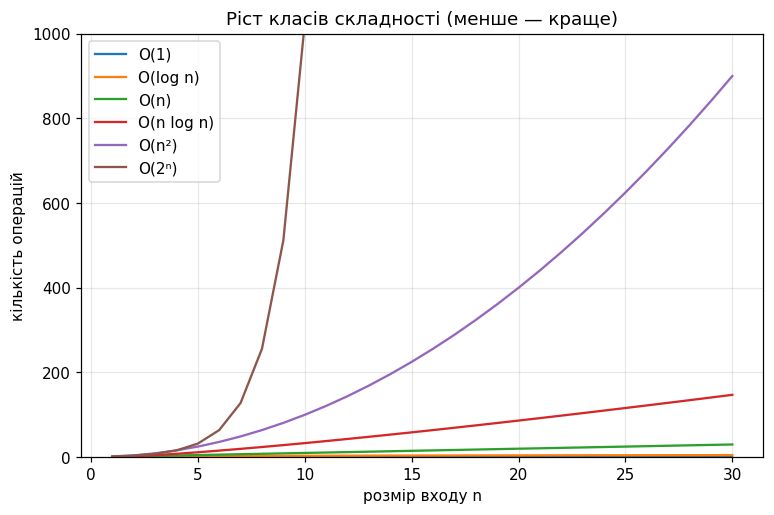

In [3]:
# Графік: як ростуть класи складності зі збільшенням n
n = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n, np.ones_like(n),      label="O(1)")
ax.plot(n, np.log2(n),           label="O(log n)")
ax.plot(n, n,                    label="O(n)")
ax.plot(n, n * np.log2(n),       label="O(n log n)")
ax.plot(n, n ** 2,               label="O(n²)")
ax.plot(n, 2.0 ** n,             label="O(2ⁿ)")
ax.set_ylim(0, 1000)
ax.set_xlabel("розмір входу n")
ax.set_ylabel("кількість операцій")
ax.set_title("Ріст класів складності (менше — краще)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 4. Як рахувати складність коду

Практичні правила на прикладах:

- **Проста операція** (присвоєння, порівняння, `arr[i]`) → **O(1)**.
- **Один цикл** до `n` → **O(n)**.
- **Вкладені цикли** до `n` → перемножуємо → **O(n²)**.
- **Послідовні** блоки → додаємо й лишаємо більший: O(n) + O(n²) = **O(n²)**.
- **Ділення задачі навпіл** щоразу → **O(log n)** (як двійковий пошук).

In [4]:
# O(1): скільки б не було елементів — фіксована кількість дій
def first_element(arr):
    return arr[0] if arr else None

# O(n): один прохід
def total(arr):
    s = 0
    for x in arr:        # n ітерацій
        s += x
    return s

# O(n^2): вкладені цикли -> шукаємо, чи є пара з однаковим значенням (наївно)
def has_dup_naive(arr):
    for i in range(len(arr)):            # n
        for j in range(i + 1, len(arr)): # ~n
            if arr[i] == arr[j]:
                return True
    return False

# O(n): те саме, але через множину (пам'ять O(n) в обмін на швидкість)
def has_dup_fast(arr):
    seen = set()
    for x in arr:                        # n, а `x in seen` — O(1) у середньому
        if x in seen:
            return True
        seen.add(x)
    return False

data = [3, 1, 4, 1, 5]
print("total:", total(data))
print("naive O(n^2):", has_dup_naive(data))
print("fast  O(n)  :", has_dup_fast(data))

total: 14
naive O(n^2): True
fast  O(n)  : True


> 🔎 **Важливо знати — компроміс «час vs пам'ять».** `has_dup_fast` швидший (O(n) проти O(n²)),
> але витрачає **додаткову пам'ять** O(n) на множину. Це типовий інженерний обмін: часто можна
> прискорити алгоритм ціною пам'яті (і навпаки). На співбесіді завжди озвучуйте **обидві**
> складності — часову й просторову.

## 5. Часова й просторова складність

- **Часова (time)** — скільки **операцій**.
- **Просторова (space)** — скільки **додаткової пам'яті** (крім самого входу).

Приклади просторової:
- проста сума в циклі — **O(1)** пам'яті (одна змінна);
- копія масиву / множина `seen` — **O(n)** пам'яті;
- рекурсія — пам'ять **O(глибини стека викликів)** (див. розділ 7).

### Best / Average / Worst case
Складність може залежати від конкретних даних:
- **worst (найгірший)** — найпесимістичніший вхід (зазвичай саме його й наводять);
- **average (середній)** — усереднення по всіх входах;
- **best (найкращий)** — найщасливіший вхід.

Приклад — лінійний пошук у масиві з `n` елементів: best = O(1) (елемент перший),
worst = O(n) (елемент останній або відсутній), average = O(n).

## 6. 🔎 Амортизована складність

Іноді **одна** операція зрідка буває дорогою, але **в середньому по багатьох** — дешева. Це
**амортизований** аналіз. Класика — `list.append` у Python.

Python-список — це **динамічний масив**. Коли місце закінчується, він виділяє **більший** блок
(зазвичай ~в 1.125–2 рази) і копіює елементи — це разова дорога операція O(n). Але таке
розширення трапляється **рідко**, тому *в середньому* один `append` коштує **O(1)** — кажуть
«амортизовано O(1)».

In [5]:
# Подивимось, як ємність (місткість) списку зростає стрибками, а не на кожен append.
import sys

arr = []
prev = -1
print("довжина -> зарезервована місткість (стрибки = моменти перевиділення):")
for i in range(20):
    arr.append(i)
    # оцінка місткості через розмір об'єкта (грубо, для наочності)
    cap = (sys.getsizeof(arr) - sys.getsizeof([])) // 8
    if cap != prev:
        print(f"  len={len(arr):>2}  місткість≈{cap}")
        prev = cap
print("\nПеревиділення трапляється рідко -> у середньому append це O(1) (амортизовано).")

довжина -> зарезервована місткість (стрибки = моменти перевиділення):
  len= 1  місткість≈4
  len= 5  місткість≈8
  len= 9  місткість≈16
  len=17  місткість≈24

Перевиділення трапляється рідко -> у середньому append це O(1) (амортизовано).


## 7. Рекурсія

**Рекурсія** — коли функція викликає саму себе. Дві обов'язкові частини:
1. **База (base case)** — умова зупинки (без неї — нескінченність і `RecursionError`);
2. **Крок** — зведення задачі до **меншої** тієї ж задачі.

Кожен виклик кладе **кадр** на **стек викликів** (call stack) — звідси просторова складність
рекурсії = **O(глибини)**.

In [6]:
# Класика: факторіал n! = n * (n-1)!
def factorial(n):
    if n <= 1:          # база
        return 1
    return n * factorial(n - 1)   # крок: зводимо до меншого n

print("5! =", factorial(5))       # 120

# Візуалізація стека викликів для factorial(4):
#   factorial(4)
#     -> 4 * factorial(3)
#          -> 3 * factorial(2)
#               -> 2 * factorial(1)
#                    -> 1          (база)
# розкручування назад: 2*1=2 -> 3*2=6 -> 4*6=24
print("4! =", factorial(4))       # 24

# Глибина рекурсії обмежена (за замовчуванням ~1000):
import sys
print("ліміт рекурсії Python:", sys.getrecursionlimit())

5! = 120
4! = 24
ліміт рекурсії Python: 3000


### Проблема повторних обчислень

Наївний рекурсивний Фібоначчі **перераховує** одне й те саме безліч разів → експоненційно O(2ⁿ).
Порахуймо реальну кількість викликів.

In [7]:
# Наївний Фібоначчі: рахуємо, СКІЛЬКИ разів викликається функція
calls = {"n": 0}
def fib_naive(n):
    calls["n"] += 1
    if n < 2:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

calls["n"] = 0
print("fib(20) =", fib_naive(20), "| викликів:", calls["n"])   # ~13500 викликів!

# Мемоізація: запам'ятовуємо вже пораховане -> O(n)
memo = {}
calls["n"] = 0
def fib_memo(n):
    calls["n"] += 1
    if n < 2:
        return n
    if n in memo:
        return memo[n]
    memo[n] = fib_memo(n - 1) + fib_memo(n - 2)
    return memo[n]

print("fib(20) =", fib_memo(20), "| викликів:", calls["n"])    # набагато менше
print("\nМемоізація перетворила O(2^n) на O(n) — детальніше в Уроці 6 (динамічне програмування).")

fib(20) = 6765 | викликів: 21891
fib(20) = 6765 | викликів: 39

Мемоізація перетворила O(2^n) на O(n) — детальніше в Уроці 6 (динамічне програмування).


## 8. 🔎🚀 Master-теорема (Middle+)

Для алгоритмів «**розділяй і володарюй**», що ділять задачу на `a` підзадач розміру `n/b` і
витрачають O(nᵈ) на «склеювання», рекурентність має вигляд:

```
T(n) = a · T(n/b) + O(n^d)
```

Master-теорема одразу дає відповідь, порівнюючи `d` з `log_b(a)`:

| Умова | Складність | Приклад |
|-------|-----------|---------|
| d > log_b(a) | Θ(nᵈ) | — |
| d = log_b(a) | Θ(nᵈ·log n) | **merge sort**: a=2, b=2, d=1 → Θ(n log n) |
| d < log_b(a) | Θ(n^log_b(a)) | множення Штрассена |

Junior-у досить **розуміти ідею** (як з рекурентності дістати складність); напам'ять формулу —
рівень Middle+. Але **чому merge sort — це O(n log n)**, знати варто (спитають).

# ✅ Підсумок уроку
- **Асимптотика** описує ріст часу/пам'яті від `n`, ігноруючи константи; **O** — зверху, **Ω** — знизу, **Θ** — точно.
- **Класи:** O(1) < O(log n) < O(n) < O(n log n) < O(n²) < O(2ⁿ) < O(n!).
- **Рахунок:** цикл = O(n), вкладені = множимо, послідовні = беремо більший, ділення навпіл = O(log n).
- **Час vs пам'ять** — типовий компроміс (пришвидшити ціною пам'яті).
- **Амортизована** O(1) — як `list.append` (рідкі дорогі перевиділення усереднюються).
- **Рекурсія** = база + крок; пам'ять O(глибини); наївне повторне обчислення → O(2ⁿ), лікується **мемоізацією**.
- **Master-теорема** дає складність «розділяй і володарюй» (напр. merge sort = Θ(n log n)).

### ▶️ Далі
Урок 2 — **базові структури даних** (масиви, зв'язані списки, стек, черга, хеш-таблиці).

### 📚 Хочу знати більше
- Big-O Cheat Sheet: <https://www.bigocheatsheet.com/>
- Складність операцій Python (TimeComplexity): <https://wiki.python.org/moin/TimeComplexity>
- VisuAlgo (візуалізації): <https://visualgo.net/>
- Master theorem: <https://en.wikipedia.org/wiki/Master_theorem_(analysis_of_algorithms)>